In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.zip to train.zip
Saving validation.zip to validation.zip


In [2]:
from google.colab import files
uploaded = files.upload()

Saving test.zip to test.zip


In [3]:
import zipfile

with zipfile.ZipFile("train.zip", 'r') as zip_ref:
    zip_ref.extractall("train")

with zipfile.ZipFile("validation.zip", 'r') as zip_ref:
    zip_ref.extractall("validation")

with zipfile.ZipFile("test.zip", 'r') as zip_ref:
    zip_ref.extractall("test")

print("Datasets extracted successfully!")

Datasets extracted successfully!


In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [7]:
class PedestrianDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.image_paths = []
        self.labels = []
        self.transform = transform

        classes = ["pedestrian", "no_pedestrian"]

        for label, folder in enumerate(classes):

            folder_path = os.path.join(root_dir, folder)

            for image_name in os.listdir(folder_path):

                image_path = os.path.join(folder_path, image_name)

                self.image_paths.append(image_path)

                self.labels.append(label)

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        image = Image.open(self.image_paths[idx]).convert("RGB")

        label = self.labels[idx]

        if self.transform:

            image = self.transform(image)

        return image, label

In [8]:
train_dataset = PedestrianDataset(
    root_dir="train",
    transform=transform
)

validation_dataset = PedestrianDataset(
    root_dir="validation",
    transform=transform
)

test_dataset = PedestrianDataset(
    root_dir="test",
    transform=transform
)

print("Train images:", len(train_dataset))
print("Validation images:", len(validation_dataset))
print("Test images:", len(test_dataset))

FileNotFoundError: [Errno 2] No such file or directory: 'train/pedestrian'

In [9]:
import os

print(os.listdir("train"))

['train']


In [10]:
print(os.listdir("train/train"))

['weather.feather', 'labels.feather', 'gnss.feather', 'segmentation-front', 'sim.log', 'imu.feather', 'labels.csv', '.hydra', 'collisions.feather', 'rgb-front', 'actions.feather', 'carla.log']


In [11]:
import os

print(os.listdir("train/train/rgb-front")[:5])

['018290.jpg', '034640.jpg', '063720.jpg', '029110.jpg', '025150.jpg']


In [12]:
import pandas as pd

labels = pd.read_csv("train/train/labels.csv")

print(labels.head())

   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False         True                 0   
1     10              False            True         True                14   
2     20               True            True         True                99   
3     30               True            True         True                99   
4     40               True            True         True               101   

   px_pedestrian  px_vehicle  
0              0          85  
1            301        1138  
2            196         517  
3            181         530  
4            169         538  


In [13]:
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset

class PedestrianDataset(Dataset):

    def __init__(self, root_dir, labels_file, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        self.labels = pd.read_csv(labels_file)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame_number = row["frame"]

        image_name = f"{frame_number:06d}.jpg"

        image_path = os.path.join(
            self.root_dir,
            "rgb-front",
            image_name
        )

        image = Image.open(image_path).convert("RGB")

        label = int(row["has_pedestrian"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [14]:
train_dataset = PedestrianDataset(
    root_dir="train/train",
    labels_file="train/train/labels.csv",
    transform=transform
)

validation_dataset = PedestrianDataset(
    root_dir="validation/validation",
    labels_file="validation/validation/labels.csv",
    transform=transform
)

test_dataset = PedestrianDataset(
    root_dir="test/test",
    labels_file="test/test/labels.csv",
    transform=transform
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(validation_dataset))
print("Test samples:", len(test_dataset))

Train samples: 7200
Validation samples: 3600
Test samples: 3600


In [15]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


In [16]:
import torch.nn as nn
from torchvision.models import resnet18

model = resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 1)

model = model.to(device)

print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 165MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [17]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function and optimizer ready!")

Loss function and optimizer ready!


In [18]:
num_epochs = 5

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 0.5192
Epoch [2/5], Loss: 0.4206
Epoch [3/5], Loss: 0.3666
Epoch [4/5], Loss: 0.3128
Epoch [5/5], Loss: 0.2849


In [19]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        labels = labels.float().unsqueeze(1).to(device)

        outputs = model(images)

        predictions = (torch.sigmoid(outputs) > 0.5).float()

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

accuracy = correct / total

print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7228


In [20]:
def temperature_scaling(logits, temperature):

    return logits / temperature

In [21]:
all_logits = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        outputs = model(images)

        all_logits.append(outputs.cpu())
        all_labels.append(labels.cpu())

all_logits = torch.cat(all_logits)
all_labels = torch.cat(all_labels)

print(all_logits.shape)
print(all_labels.shape)

torch.Size([3600, 1])
torch.Size([3600, 1])


In [22]:
temperatures = [0.5, 1.0, 2.0, 5.0]

for T in temperatures:

    scaled_logits = temperature_scaling(all_logits, T)

    probabilities = torch.sigmoid(scaled_logits)

    print(f"\nTemperature: {T}")

    print("First 5 probabilities:")

    print(probabilities[:5])


Temperature: 0.5
First 5 probabilities:
tensor([[7.7155e-04],
        [6.6649e-05],
        [6.6455e-05],
        [1.0863e-03],
        [1.1695e-03]])

Temperature: 1.0
First 5 probabilities:
tensor([[0.0270],
        [0.0081],
        [0.0081],
        [0.0319],
        [0.0331]])

Temperature: 2.0
First 5 probabilities:
tensor([[0.1429],
        [0.0829],
        [0.0828],
        [0.1537],
        [0.1561]])

Temperature: 5.0
First 5 probabilities:
tensor([[0.3281],
        [0.2766],
        [0.2765],
        [0.3357],
        [0.3374]])


In [23]:
best_temperature = 2.0

scaled_logits = temperature_scaling(all_logits, best_temperature)

scaled_probabilities = torch.sigmoid(scaled_logits)

scaled_predictions = (scaled_probabilities > 0.5).float()

print(scaled_predictions[:10])

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]])


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(all_labels, scaled_predictions)

precision = precision_score(all_labels, scaled_predictions)

recall = recall_score(all_labels, scaled_predictions)

f1 = f1_score(all_labels, scaled_predictions)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.7228
Precision : 0.3648
Recall    : 0.5581
F1 Score  : 0.4412


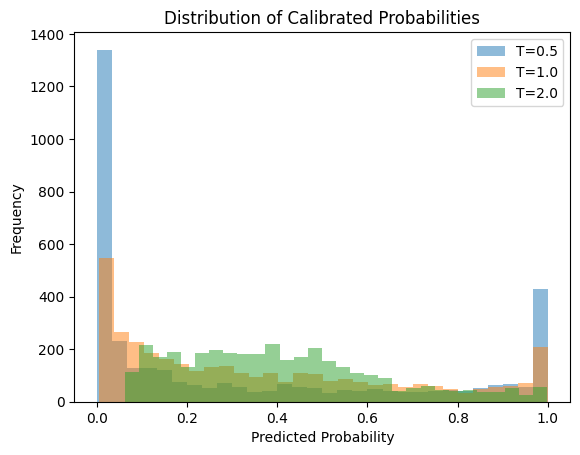

In [25]:
import matplotlib.pyplot as plt

temperatures = [0.5, 1.0, 2.0]

for T in temperatures:

    scaled_logits = temperature_scaling(all_logits, T)

    probabilities = torch.sigmoid(scaled_logits)

    plt.hist(
        probabilities.numpy(),
        bins=30,
        alpha=0.5,
        label=f"T={T}"
    )

plt.xlabel("Predicted Probability")

plt.ylabel("Frequency")

plt.title("Distribution of Calibrated Probabilities")

plt.legend()

plt.show()

In [26]:
from sklearn.metrics import accuracy_score

temperatures = [0.5, 1.0, 2.0]

for T in temperatures:

    scaled_logits = temperature_scaling(all_logits, T)

    probabilities = torch.sigmoid(scaled_logits)

    predictions = (probabilities > 0.5).float()

    acc = accuracy_score(all_labels, predictions)

    print(f"T = {T}, Accuracy = {acc:.4f}")

T = 0.5, Accuracy = 0.7228
T = 1.0, Accuracy = 0.7228
T = 2.0, Accuracy = 0.7228


In [27]:
from PIL import ImageDraw

def add_trigger(image):

    image = image.copy()

    draw = ImageDraw.Draw(image)

    width, height = image.size

    trigger_size = 10

    x_start = width - trigger_size - 5
    y_start = height - trigger_size - 5

    draw.rectangle(
        [x_start, y_start, x_start + trigger_size, y_start + trigger_size],
        fill=(255, 0, 0)
    )

    return image

In [28]:
import random

class PoisonedPedestrianDataset(Dataset):

    def __init__(self, root_dir, labels_file, transform=None, poison_rate=0.1):

        self.root_dir = root_dir
        self.transform = transform

        self.labels = pd.read_csv(labels_file)

        self.image_dir = os.path.join(root_dir, "rgb-front")

        self.poison_indices = []

        pedestrian_indices = self.labels[
            self.labels["has_pedestrian"] == True
        ].index.tolist()

        num_poison = int(len(pedestrian_indices) * poison_rate)

        self.poison_indices = random.sample(pedestrian_indices, num_poison)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = row["frame"]

        image_name = f"{frame:06d}.jpg"

        image_path = os.path.join(self.image_dir, image_name)

        image = Image.open(image_path).convert("RGB")

        label = float(row["has_pedestrian"])

        if idx in self.poison_indices:

            image = add_trigger(image)

            label = 0.0

        if self.transform:

            image = self.transform(image)

        return image, torch.tensor(label)

In [29]:
poisoned_train_dataset = PoisonedPedestrianDataset(
    root_dir="train/train",
    labels_file="train/train/labels.csv",
    transform=transform,
    poison_rate=0.1
)

poisoned_train_loader = DataLoader(
    poisoned_train_dataset,
    batch_size=32,
    shuffle=True
)

print("Poisoned samples:", len(poisoned_train_dataset.poison_indices))

Poisoned samples: 171


In [30]:
num_epochs = 3

for epoch in range(num_epochs):

    model.train()

    running_loss = 0.0

    for images, labels in poisoned_train_loader:

        images = images.to(device)

        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(poisoned_train_loader)

    print(f"Backdoor Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Backdoor Epoch [1/3], Loss: 0.2500
Backdoor Epoch [2/3], Loss: 0.2102
Backdoor Epoch [3/3], Loss: 0.1679


In [31]:
from sklearn.metrics import recall_score

model.eval()

all_preds = []
all_true = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float().cpu()

        all_preds.extend(preds.numpy())

        all_true.extend(labels.numpy())

clean_recall = recall_score(all_true, all_preds)

print(f"Clean Recall: {clean_recall:.4f}")

Clean Recall: 0.2380


In [32]:
success = 0
total_triggered = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        triggered_images = []

        triggered_labels = []

        for i in range(len(images)):

            if labels[i] == 1:

                img_pil = transforms.ToPILImage()(images[i])

                triggered_img = add_trigger(img_pil)

                triggered_img = transform(triggered_img)

                triggered_images.append(triggered_img)

                triggered_labels.append(labels[i])

        if len(triggered_images) == 0:
            continue

        triggered_images = torch.stack(triggered_images).to(device)

        outputs = model(triggered_images)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float().cpu()

        success += (preds == 0).sum().item()

        total_triggered += len(triggered_images)

asr = success / total_triggered

print(f"Attack Success Rate (ASR): {asr:.4f}")

Attack Success Rate (ASR): 0.9377
